In [1]:
import sys
sys.path.append("../")
from fastai.text import *
from utils import *
import selfies as sf

/home/jerry/anaconda3/envs/iMiner/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2023-01-12 14:48:03.648977: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-01-12 14:48:05.718129: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda/lib64::/home/jerry/.mujoco/mujoco200/bin/
2023-01-12 14:48:05.718334: W tensorflow/compiler/xla/stream_executo

In [2]:
data=load_data('../data/','databunch-production-SELFIES.pkl', bs=512, bptt=70)
model=language_model_learner(data,AWD_LSTM)
model.path=Path("../outputs")
model.load("checkpoint_29")
underlying_model=model.model.eval()
tokens=data.train_ds.x.vocab.itos
sampler=SELFIES_Sampler(underlying_model, tokens)

In [3]:
results=sampler.sample(10, do_batch=True, batch_size=512)

In [10]:
from guacamol.distribution_matching_generator import DistributionMatchingGenerator
class TXLGenerator(DistributionMatchingGenerator):
    def __init__(self, sampler):
        self.sampler=sampler
        
    def generate(self,number_samples):
        selfies_samples=self.sampler.sample(number_samples, do_batch=True, batch_size=512)
        samples=[]
        for s in selfies_samples:
            try:
                decoded_s=sf.decoder(s)
            except:
                decoded_s = None
            if decoded_s is None:
                samples.append("|||CANNOT_DECODE|||")
            else:
                samples.append(decoded_s)
        return samples
from guacamol.assess_distribution_learning import assess_distribution_learning

gen=TXLGenerator(sampler)
assess_distribution_learning(gen,"../data/chembl.txt")

2023-01-12 16:28:50.667002: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
results

['[N][C][=N][C][Branch1][C][S][=C][Branch1][C][I][C][Branch1][Branch2][N][C][C][C][C][Ring1][Branch1][=N][Ring1][=N]',
 '[O][=C][Branch1][#C][C][C][C][C][C][C][C][=C][C][=C][C][=C][Ring1][=Branch1][C][=N][C][=C][Branch1][=Branch2][C][=C][C][=C][C][=N][Ring1][=Branch1][O][Ring1][O]',
 '[C][N][N][=C][C][=C][C][Branch2][Ring1][C][N][C][=Branch1][C][=O][C][C][Branch1][C][N][C][C][C][C][C][Ring1][#Branch1][=C][C][=C][Ring1][P][Ring2][Ring1][Ring2]',
 '[N-1][=N+1][=N][C][C@H1][Branch2][Ring1][Branch1][N][C][=N][C][=N][C][C][Ring1][=Branch1][=N][N][C][=C][C][=C][C][=Ring1][=Branch2][Ring1][=Branch1][C][=C][C][=C][C][=C][Ring1][=Branch1]',
 '[C][O][C][=C][C][=C][C][=C][Ring1][=Branch1][N][C][=C][Branch2][Ring1][#Branch1][C][O][C][=Branch1][C][=O][/C][=C][/C][=C][C][=C][Branch1][C][O][C][Branch1][C][O][=C][Ring1][Branch2][N][=N][Ring2][Ring1][Ring1]',
 '[C][C][O][C][=Branch1][C][=O][C][S][C][N][=C][Branch1][S][C][C][N][C][=Branch1][C][=O][C][=C][C][=C][C][=C][Ring1][=Branch1][N][Branch1][C][C][

In [5]:
sm=[sf.decoder(r) for r in results]

In [6]:
sm

['NC1=NC(S)=C(I)C(N2CCCC2)=N1',
 'O=C(CCCCCCC1=CC=CC=C1)C2=NC=C(C3=CC=CC=N3)O2',
 'CN1N=CC2=CC(NC(=O)CC3(N)CCCCC3)=CC=C21',
 '[N-1]=[N+1]=NC[C@H1](NC1=NC=NC=2C1=NN3C=CC=CC=23)C4=CC=CC=C4',
 'COC1=CC=CC=C1N2C=C(COC(=O)/C=C/C3=CC=C(O)C(O)=C3)N=N2',
 'CCOC(=O)C=1SC=2N=C(CCNC(=O)C3=CC=CC=C3)N(C)C(=O)C=2C=1C',
 'CC[C@H1](NS(=O)(=O)CCCOCN1C=CC(=O)[NH1]C1)OC2=CC=CC(OCC(F)F)=C2',
 'CC(=O)O[C@@H1][C@@H1]1CC[C@H1]([C@@H1](C)CCCC(=O)O)[C@@]1(C)/C=C/[C@H1](O)C2[C@](C)C(C)=CC[C@]2C',
 'C[C@H1]1CN([C@H1](C)CO)C(=O)C2=CC=CC=C2C3=CC=CC=C3CO[C@@H1]1CN(C)S(=O)(=O)C4=CN(C)C=N4',
 'COC1=CC(OC)=CC(N(CC#CC2=CC(C#N)=CC=N2)C3=CC=C4N=CC(C=5C=NN(C)C=5)=NC4=C3)=C1']

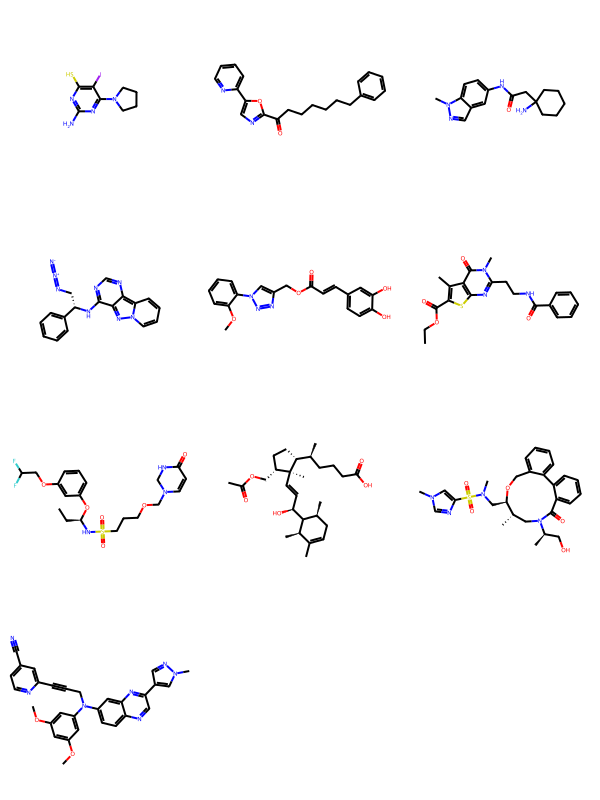

In [7]:
from rdkit.Chem import Draw
from rdkit import Chem
mols=[Chem.MolFromSmiles(s) for s in sm]
Draw.MolsToGridImage(mols)

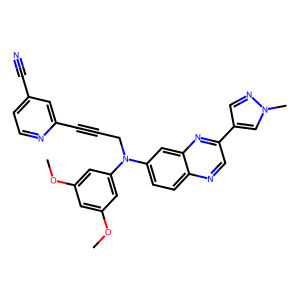

In [8]:
Draw.MolToImage(Chem.MolFromSmiles(sm[9]))

In [3]:
import pandas as pd

In [4]:
pd.__version__

'1.2.3'